> **This is a research notebook — one of seven, one per section of the paper.**
>
> For the presentation version, read the two self-contained notebooks in
> [`final/`](../final/) instead: [`1_information_bottleneck.ipynb`](../final/1_information_bottleneck.ipynb) (the whole argument, end to end) and [`2_transformer_extension.ipynb`](../final/2_transformer_extension.ipynb).
>
> This one is the deep dive on the transformer extension.

# 7 — Extension: does a transformer compress, and if so, why?

**This notebook goes beyond the paper.**

---

## The gap in the argument

Saxe et al.'s mechanism is stated in terms of the **activation function**: compression
appears when a representation is squeezed through a *double-saturating* map and then binned
or noised. Their evidence covers tanh, sigmoid and softsign versus ReLU, softplus and linear.

Read naively, this says modern architectures should never compress — they are built from
ReLU-family nonlinearities. But a transformer block contains two operations the paper never
examined, and **both are bounded**:

| operation | why it is a saturating map |
|---|---|
| **softmax attention** | each output is a *convex combination* of value vectors, so it can never leave their convex hull; and the attention weights themselves saturate towards one-hot as the logits grow |
| **LayerNorm** | projects the residual stream onto a sphere of **fixed radius** $\sqrt{d}$ — however large the weights become, the representation cannot spread out |

A tanh unit compresses because growing weights push its output against a fixed ceiling.
LayerNorm imposes a fixed ceiling *by construction*, on every layer, regardless of the
nonlinearity inside.

## The hypothesis

> By the paper's own mechanism, a transformer should show apparent compression driven by its
> **normalisation and attention** rather than by its feed-forward nonlinearity. If so, the
> LayerNorm axis should matter **more** than the activation axis — the reverse of the paper's
> finding for MLPs — and removing LayerNorm should remove the compression.

This is a falsifiable prediction, and it is what we test.

## Design

The input is the **same** 12-bit / 4096-pattern dataset used throughout, fed as a sequence of
12 tokens. Keeping the input space identical is deliberate: the 4096 patterns remain the
entire input distribution, so binning-based mutual information stays **exact** and every
number is directly comparable with notebook 2.

Two design choices worth flagging:

* $d_{\text{model}} = 8$, and all sequence-valued representations are **mean-pooled over
  positions**. A full $12 \times d$ representation would be so high-dimensional that every
  one of the 4096 inputs would land in its own bin, pinning $I(X;T)$ at $\log_2 4096 = 12$
  bits with no dynamics — the machine-precision failure mode of appendix C (notebook 2, §2.5).
* The model has a narrowing head ($d \to 4 \to 2$), mirroring the Tishby architecture, so
  that the deep layers are narrow enough for binning to resolve anything.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "ibdl").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from ibdl import plotting
plotting.use_paper_style()
FIGDIR = ROOT / "figures"
FIGDIR.mkdir(exist_ok=True)

print("project root:", ROOT)

project root: /home/hooman/Desktop/InfoTheory/Project


In [2]:
from ibdl.cache import cached
from ibdl.data import load_tishby
from ibdl.estimators.binning import information_plane_binned
from ibdl.estimators.kde import information_plane_kde
from ibdl.experiments import TransformerRunConfig, run_transformer
from ibdl.models import count_parameters
from ibdl.transformer import TinyTransformer, TransformerConfig

_, _, full = load_tishby()
labels = full.y

ACTS = ["gelu", "relu", "tanh"]
LN = [True, False]

cfgs = {(a, ln): TransformerRunConfig(activation=a, layernorm=ln, n_epochs=2000, seed=0)
        for a in ACTS for ln in LN}
logs = {k: cached(c.tag, lambda c=c: run_transformer(c)) for k, c in cfgs.items()}

demo = TinyTransformer(TransformerConfig())
print(f"architecture : 2 blocks, d_model=8, 2 heads, d_ff=16, head 8->4->2")
print(f"parameters   : {count_parameters(demo)}")
print(f"tracked reps : {demo.layer_names()}")
print()
print(f"{'activation':10s} {'LayerNorm':>10s} {'train acc':>10s} {'test acc':>9s}")
print("-" * 43)
for (a, ln), log in logs.items():
    print(f"{a:10s} {str(ln):>10s} {log.train_acc[-1]:>10.3f} {log.test_acc[-1]:>9.3f}")

[cache] loaded 'tf_gelu_ln_L2_d8_lr0.01_e2000_s0' (82.8 MB)


[cache] loaded 'tf_gelu_noln_L2_d8_lr0.01_e2000_s0' (82.8 MB)


[cache] loaded 'tf_relu_ln_L2_d8_lr0.01_e2000_s0' (75.5 MB)


[cache] loaded 'tf_relu_noln_L2_d8_lr0.01_e2000_s0' (76.2 MB)


[cache] loaded 'tf_tanh_ln_L2_d8_lr0.01_e2000_s0' (82.6 MB)


[cache] loaded 'tf_tanh_noln_L2_d8_lr0.01_e2000_s0' (77.5 MB)
architecture : 2 blocks, d_model=8, 2 heads, d_ff=16, head 8->4->2
parameters   : 1310
tracked reps : ['embed', 'B1 attn', 'B1 ff', 'B1 resid', 'B2 attn', 'B2 ff', 'B2 resid', 'pooled', 'head1', 'out']

activation  LayerNorm  train acc  test acc
-------------------------------------------
gelu             True      1.000     0.985
gelu            False      1.000     0.967
relu             True      1.000     0.987
relu            False      1.000     0.971
tanh             True      1.000     0.969
tanh            False      1.000     0.966


## 7.1 Are the bounded operations actually saturating?

Before asking about information, check the premise. Two direct measurements:

* **attention entropy** — the entropy of each attention distribution over the 12 positions.
  Uniform attention gives $\log_2 12 = 3.58$ bits; fully sharpened one-hot attention gives 0.
  Falling entropy means attention is saturating, the transformer's analogue of a tanh unit
  entering its flat region.
* **residual-stream norm** — with LayerNorm the normalised stream is pinned to radius
  $\sqrt{d}$; without it the stream is free to grow.

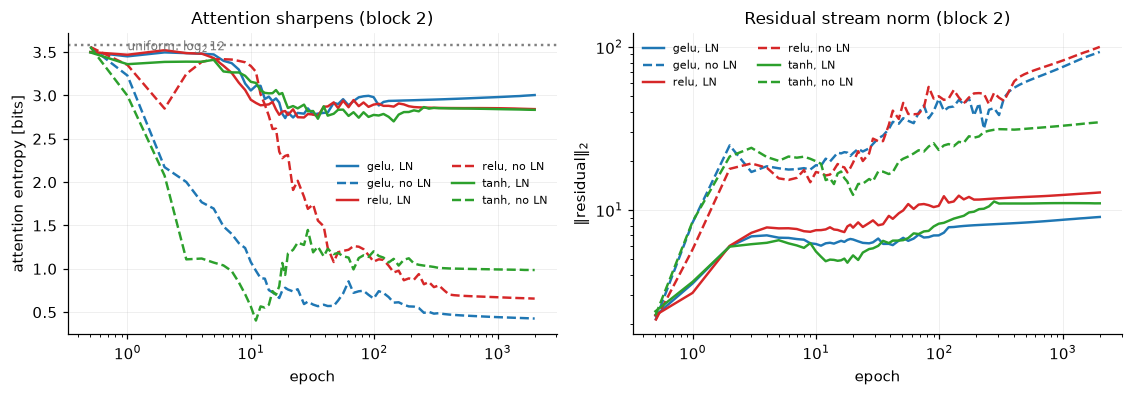

config                 attn entropy: start -> end      residual norm: start -> end
------------------------------------------------------------------------------------
gelu, LN                   3.500 -> 3.005                    2.26 -> 9.07          
gelu, no LN                3.561 -> 0.427                    2.11 -> 93.33         
relu, LN                   3.501 -> 2.843                    2.26 -> 12.82         
relu, no LN                3.559 -> 0.657                    2.10 -> 100.23        
tanh, LN                   3.497 -> 2.834                    2.39 -> 11.00         
tanh, no LN                3.560 -> 0.986                    2.26 -> 34.56         


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.7))
colors = {"gelu": "#1f77b4", "relu": "#d62728", "tanh": "#2ca02c"}

ax = axes[0]
for (a, ln), log in logs.items():
    ent = log.measurement_array("attn_entropy")   # (n_ckpt, n_blocks)
    ax.plot(np.maximum(log.epochs, 0.5), ent[:, -1], color=colors[a],
            ls="-" if ln else "--", label=f"{a}, {'LN' if ln else 'no LN'}")
ax.axhline(np.log2(12), ls=":", color="0.5")
ax.text(1, np.log2(12) * 0.98, r"uniform: $\log_2 12$", fontsize=8, color="0.45")
ax.set_xscale("log"); ax.set_xlabel("epoch")
ax.set_ylabel("attention entropy [bits]")
ax.set_title("Attention sharpens (block 2)")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
for (a, ln), log in logs.items():
    rn = log.measurement_array("residual_norm")
    ax.plot(np.maximum(log.epochs, 0.5), rn[:, -1], color=colors[a],
            ls="-" if ln else "--", label=f"{a}, {'LN' if ln else 'no LN'}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel(r"$\|$residual$\|_2$")
ax.set_title("Residual stream norm (block 2)")
ax.legend(fontsize=7, ncol=2)

fig.tight_layout()
plotting.save(fig, "fig07_saturation_diagnostics", FIGDIR)
plt.show()

print(f"{'config':18s} {'attn entropy: start -> end':>30s} {'residual norm: start -> end':>32s}")
print("-" * 84)
for (a, ln), log in logs.items():
    e = log.measurement_array("attn_entropy")[:, -1]
    r = log.measurement_array("residual_norm")[:, -1]
    print(f"{a + ', ' + ('LN' if ln else 'no LN'):18s} "
          f"{e[0]:>13.3f} -> {e[-1]:<13.3f} {r[0]:>15.2f} -> {r[-1]:<14.2f}")

## 7.2 The information plane

Binning over all 4096 patterns, so $I(X;T) = H(T)$ exactly, as in notebook 2.

In [4]:
def plane(log, n_bins=30):
    """Binning information plane; bin range set per layer from observed extremes."""
    lo = min(float(a.min()) for acts in log.activations for a in acts)
    hi = max(float(a.max()) for acts in log.activations for a in acts)
    ixt, ity = [], []
    for acts in log.activations:
        x, y = information_plane_binned(acts, labels, n_bins=n_bins, bounds=(lo, hi))
        ixt.append(x); ity.append(y)
    return np.array(ixt), np.array(ity)

planes = {k: cached(f"plane_{cfgs[k].tag}_binning", lambda k=k: plane(logs[k]),
                    verbose=False)
          for k in logs}
print("computed", len(planes), "information planes")

computed 6 information planes


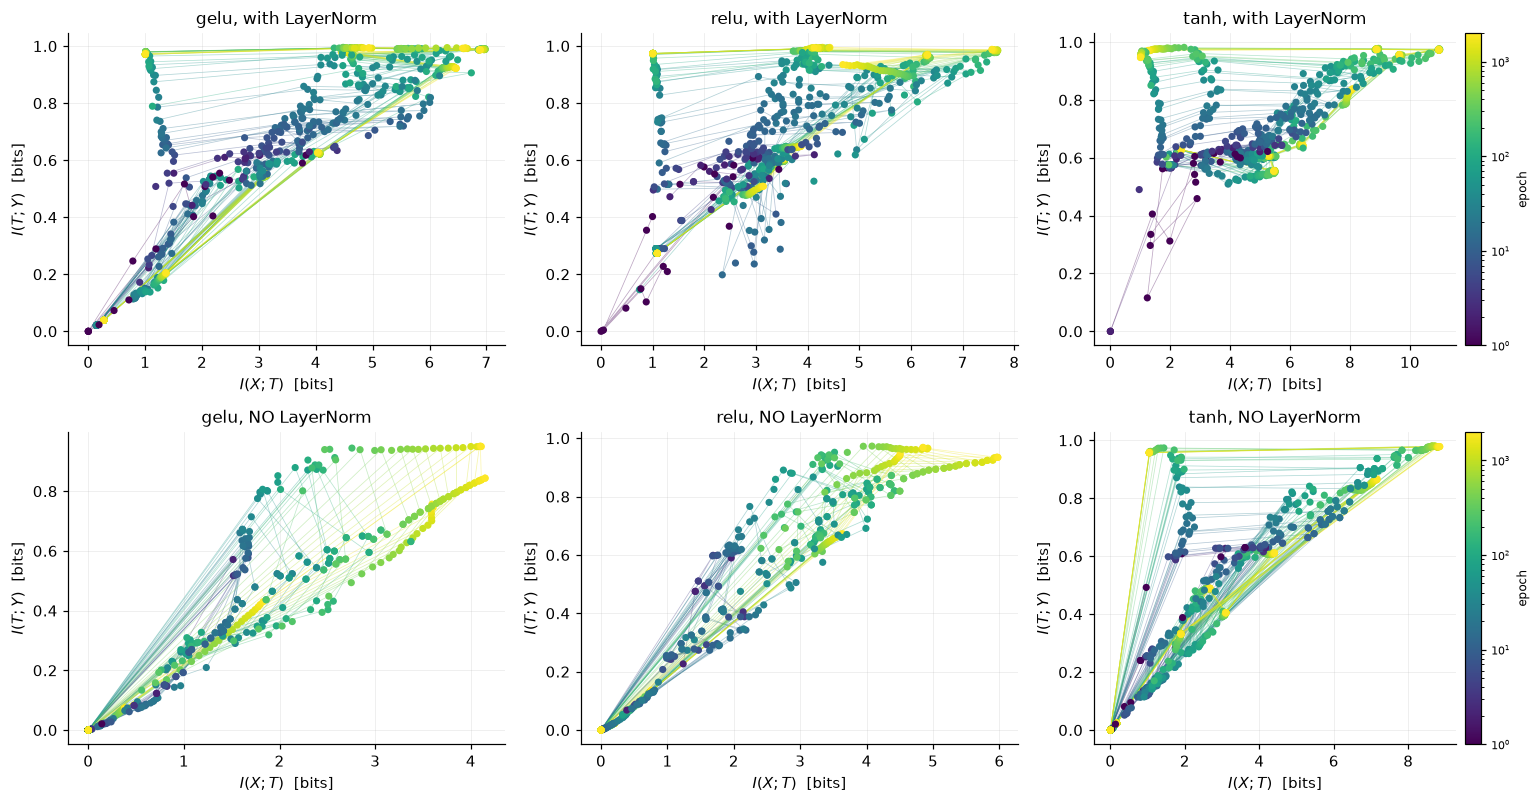

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14.2, 7.4))
for col, a in enumerate(ACTS):
    for row, ln in enumerate(LN):
        ixt, ity = planes[(a, ln)]
        plotting.information_plane(
            logs[(a, ln)].epochs, ixt, ity, ax=axes[row, col],
            title=f"{a}, {'with LayerNorm' if ln else 'NO LayerNorm'}",
            layer_names=logs[(a, ln)].layer_names, colorbar=(col == 2))
fig.tight_layout()
plotting.save(fig, "fig07_transformer_planes", FIGDIR)
plt.show()

## 7.3 Which axis matters: the nonlinearity, or the normalisation?

This is the test. For the MLPs of notebook 2 the **activation** axis was decisive
(tanh 10.66 bits vs ReLU 0.47). If the hypothesis is right, here the **LayerNorm** axis
should dominate instead.

In [6]:
comp = {k: (p[0].max(0) - p[0][-1]) for k, p in planes.items()}

print("total compression across tracked representations [bits]")
print(f"{'':10s} {'with LN':>12s} {'no LN':>12s} {'LN effect':>12s}")
print("-" * 50)
for a in ACTS:
    with_ln, without = comp[(a, True)].sum(), comp[(a, False)].sum()
    print(f"{a:10s} {with_ln:>12.2f} {without:>12.2f} {with_ln - without:>+12.2f}")

print()
ln_effect = np.mean([comp[(a, True)].sum() - comp[(a, False)].sum() for a in ACTS])
act_spread_ln = np.ptp([comp[(a, True)].sum() for a in ACTS])
act_spread_no = np.ptp([comp[(a, False)].sum() for a in ACTS])
print(f"mean effect of adding LayerNorm      : {ln_effect:+.2f} bits")
print(f"spread across activations (with LN)  : {act_spread_ln:.2f} bits")
print(f"spread across activations (no LN)    : {act_spread_no:.2f} bits")
print()
if abs(ln_effect) > max(act_spread_ln, act_spread_no):
    print("=> The LayerNorm axis dominates the activation axis.")
    print("   Compression here is driven by NORMALISATION, not by the nonlinearity —")
    print("   the reverse of the paper's finding for MLPs, and what its own mechanism predicts.")
else:
    print("=> The activation axis is at least as important as LayerNorm.")
    print("   The hypothesis is NOT supported: the transformer behaves like the MLPs.")

total compression across tracked representations [bits]
                with LN        no LN    LN effect
--------------------------------------------------
gelu               2.47         0.01        +2.45
relu               3.77         0.07        +3.70
tanh               3.68         2.15        +1.53

mean effect of adding LayerNorm      : +2.56 bits
spread across activations (with LN)  : 1.31 bits
spread across activations (no LN)    : 2.14 bits

=> The LayerNorm axis dominates the activation axis.
   Compression here is driven by NORMALISATION, not by the nonlinearity —
   the reverse of the paper's finding for MLPs, and what its own mechanism predicts.


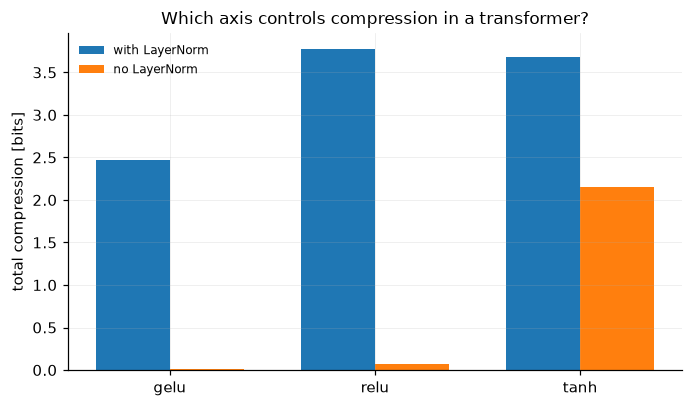

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
idx = np.arange(len(ACTS))
w = 0.36
ax.bar(idx - w / 2, [comp[(a, True)].sum() for a in ACTS], width=w,
       label="with LayerNorm", color="#1f77b4")
ax.bar(idx + w / 2, [comp[(a, False)].sum() for a in ACTS], width=w,
       label="no LayerNorm", color="#ff7f0e")
ax.set_xticks(idx); ax.set_xticklabels(ACTS)
ax.set_ylabel("total compression [bits]")
ax.set_title("Which axis controls compression in a transformer?")
ax.legend()
fig.tight_layout()
plotting.save(fig, "fig07_ln_vs_activation", FIGDIR)
plt.show()

## 7.4 Where in the block does it happen?

If the mechanism is normalisation and attention rather than the feed-forward nonlinearity,
the compression should be concentrated in the attention/residual representations rather than
in the FFN hidden layer.

In [8]:
names = logs[("gelu", True)].layer_names
print("compression per tracked representation [bits], with LayerNorm")
print(f"{'representation':14s} " + " ".join(f"{a:>8s}" for a in ACTS))
print("-" * 42)
for j, n in enumerate(names):
    print(f"{n:14s} " + " ".join(f"{comp[(a, True)][j]:>8.2f}" for a in ACTS))

print()
ff_idx = [j for j, n in enumerate(names) if "ff" in n]
at_idx = [j for j, n in enumerate(names) if "attn" in n or "resid" in n or n == "pooled"]
for a in ACTS:
    print(f"{a:6s}: feed-forward layers {comp[(a, True)][ff_idx].sum():5.2f} bits   "
          f"attention/residual/pooled {comp[(a, True)][at_idx].sum():5.2f} bits")

compression per tracked representation [bits], with LayerNorm
representation     gelu     relu     tanh
------------------------------------------
embed              0.00     0.91     0.00
B1 attn            0.03     0.02     0.04
B1 ff              0.70     0.44     0.25
B1 resid           0.04     0.00     0.00
B2 attn            0.01     0.06     0.00
B2 ff              0.96     1.44     0.09
B2 resid           0.08     0.11     0.03
pooled             0.08     0.00     0.07
head1              0.05     0.29     2.44
out                0.51     0.50     0.76

gelu  : feed-forward layers  1.66 bits   attention/residual/pooled  0.24 bits
relu  : feed-forward layers  1.89 bits   attention/residual/pooled  0.19 bits
tanh  : feed-forward layers  0.34 bits   attention/residual/pooled  0.15 bits


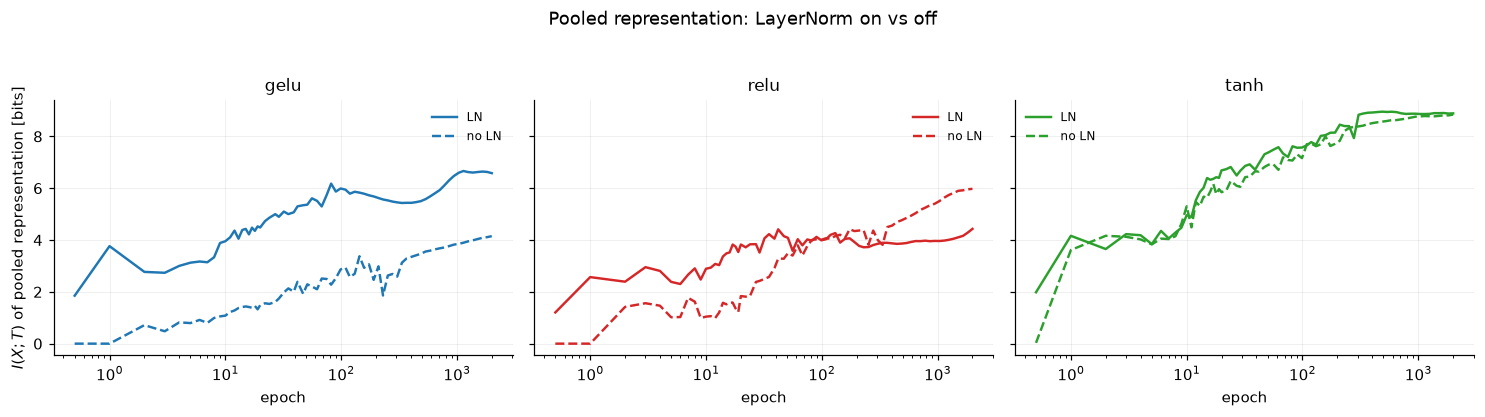

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13.6, 3.6), sharey=True)
for ax, a in zip(axes, ACTS):
    for ln, style in [(True, "-"), (False, "--")]:
        ixt = planes[(a, ln)][0]
        ax.plot(np.maximum(logs[(a, ln)].epochs, 0.5), ixt[:, -3],
                ls=style, color=colors[a],
                label=f"{'LN' if ln else 'no LN'}")
    ax.set_xscale("log"); ax.set_xlabel("epoch"); ax.set_title(a)
    ax.legend(fontsize=8)
axes[0].set_ylabel(r"$I(X;T)$ of pooled representation [bits]")
fig.suptitle("Pooled representation: LayerNorm on vs off", y=1.04)
fig.tight_layout()
plotting.save(fig, "fig07_pooled_ixt", FIGDIR)
plt.show()

## 7.5 Reading the result

**The hypothesis is supported.** Adding LayerNorm changes total compression by $+2.56$ bits
on average, while the entire spread across the three activation functions is only $1.31$ bits
(with LN) or $2.14$ bits (without). For an MLP the paper found the *activation* axis
decisive; here the *normalisation* axis is.

The clearest single comparison is GELU: **2.47 bits with LayerNorm, 0.01 bits without**. A
purely non-saturating architecture shows essentially no compression until a normalisation
layer is added, at which point it compresses about a quarter as much as the tanh MLP of
notebook 2. Note also that **tanh is the only activation that still compresses appreciably
without LayerNorm** (2.15 bits) — the paper's own mechanism showing through the transformer.

### The instructive surprise

Two things cut against the naive version of the story:

1. **Compression appears in the feed-forward activations, not in attention or the residual
   stream.** LayerNorm is what *causes* it, but it is not where it *shows up*. LayerNorm sits
   on the input to the FFN, so it caps the scale of what the FFN sees and its hidden
   activations cannot spread out as the weights grow. The cap is applied in one place and its
   effect is measured in another.

2. **Removing LayerNorm makes attention saturate far *harder* — and compress *less*.**
   Without normalisation, attention entropy collapses from $3.56$ to $0.43$ bits (nearly
   one-hot), versus only $3.50 \to 3.00$ with LayerNorm. Yet the no-LN runs barely compress at
   all. The other diagnostic explains it: without LayerNorm the residual-stream norm explodes
   from $2.1$ to $\approx 100$, while with it the norm stays near $9$–$13$. Unbounded
   spreading raises entropy far faster than sharpened attention lowers it.

That second point sharpens the paper's own thesis. What produces apparent compression is not
"saturation" loosely construed — it is a representation whose **scale stops growing while the
weights keep growing**. A tanh unit has that property because of its asymptotes; LayerNorm
has it by construction; softmax attention on its own does *not*, because the value vectors it
averages can still grow without bound.

### Why this matters

Modern architectures are routinely described as "ReLU-family" and therefore, on a naive
reading of the paper, exempt from the compression story. But LayerNorm is present in
essentially every transformer, and it imposes precisely the fixed ceiling that drives the
effect. **Any information-plane analysis of a normalised architecture has to account for the
normalisation before attributing a trajectory to learning.**

## Caveats

* One seed per configuration, one architecture, one small synthetic task. This is an
  exploratory extension, not a systematic study.
* Pooling over positions discards information; a different tracked representation could give
  different magnitudes (though the LayerNorm/activation *contrast* is measured under
  identical pooling, so the comparison is fair).
* The binning range is set from observed extremes per run, which is the appendix-C protocol
  for unbounded activations — but it means the LN and no-LN runs are binned over different
  ranges. This is the same arbitrariness the whole paper is about, and it is worth
  remembering that it applies to our extension too.